In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient
import warnings
warnings.filterwarnings('ignore')

In [5]:
client = MongoClient("mongodb://localhost:27017/")
db = client["music_db"]
tracks = db["tracks"]

In [6]:
df = pd.read_csv("/Users/alfiyaansari/Desktop/spotify_2015_2025_85k.csv")

In [36]:
df1 = pd.read_csv("/Users/alfiyaansari/Desktop/spotify_2015_2025_85k.csv")

In [4]:
#db.tracks.drop()

In [7]:
df['duration_ms'] = round(df['duration_ms'] / 60000)
df.rename(columns={"duration_ms" : "duration_minutes"},inplace=True)

In [8]:
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_minutes,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,4.0,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,6.0,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,5.0,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,3.0,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,2.0,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


In [9]:
df['release_date'] = pd.to_datetime(df['release_date'], errors = 'coerce')
df['release_year'] = df['release_date'].dt.year

In [10]:
def pop_level(x):
    if x >= 70:
        return 'High'
    elif x >= 40:
        return 'Medium'
    else:
        return 'Low'

In [11]:
df['popularity_level'] = df['popularity'].apply(pop_level)
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_minutes,popularity,danceability,energy,...,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,release_year,popularity_level
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,4.0,55,0.15,0.74,...,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,2016,Medium
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,6.0,45,0.44,0.46,...,-14.02,0,0.223,157.74,1000,France,1,Island Records,2022,Medium
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,5.0,55,0.62,0.80,...,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,2016,Medium
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,3.0,51,0.78,0.98,...,-34.47,1,0.684,149.00,1000,France,0,Warner Music,2015,Medium
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,2.0,39,0.74,0.18,...,-17.84,0,0.304,155.85,2000,United States,0,Independent,2022,Low


In [12]:
df['popularity_level'].value_counts()

popularity_level
Medium    53223
Low       24658
High       7119
Name: count, dtype: int64

In [13]:
pd.set_option('display.max_columns',50)
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_minutes,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,release_year,popularity_level
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,4.0,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,2016,Medium
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,6.0,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,2022,Medium
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,5.0,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,2016,Medium
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,3.0,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,2015,Medium
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,2.0,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,2022,Low


In [14]:
data = df.to_dict(orient="records")
tracks.insert_many(data)

InsertManyResult([ObjectId('6a18649d964bb57910551704'), ObjectId('6a18649d964bb57910551705'), ObjectId('6a18649d964bb57910551706'), ObjectId('6a18649d964bb57910551707'), ObjectId('6a18649d964bb57910551708'), ObjectId('6a18649d964bb57910551709'), ObjectId('6a18649d964bb5791055170a'), ObjectId('6a18649d964bb5791055170b'), ObjectId('6a18649d964bb5791055170c'), ObjectId('6a18649d964bb5791055170d'), ObjectId('6a18649d964bb5791055170e'), ObjectId('6a18649d964bb5791055170f'), ObjectId('6a18649d964bb57910551710'), ObjectId('6a18649d964bb57910551711'), ObjectId('6a18649d964bb57910551712'), ObjectId('6a18649d964bb57910551713'), ObjectId('6a18649d964bb57910551714'), ObjectId('6a18649d964bb57910551715'), ObjectId('6a18649d964bb57910551716'), ObjectId('6a18649d964bb57910551717'), ObjectId('6a18649d964bb57910551718'), ObjectId('6a18649d964bb57910551719'), ObjectId('6a18649d964bb5791055171a'), ObjectId('6a18649d964bb5791055171b'), ObjectId('6a18649d964bb5791055171c'), ObjectId('6a18649d964bb579105517

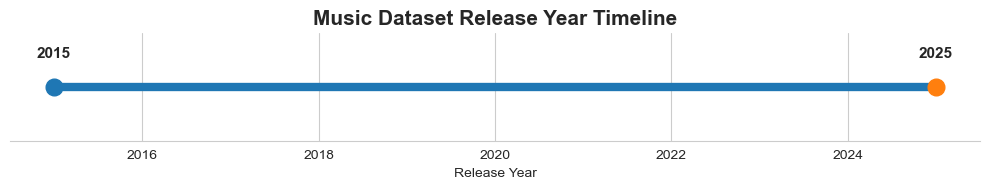

In [15]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": None,
            "maxYear": {"$max": "$release_year"},
            "minYear": {"$min": "$release_year"}
        }
    }
]))

min_year = result[0]["minYear"]
max_year = result[0]["maxYear"]
sns.set_style("whitegrid")
plt.figure(figsize=(10,2))
plt.hlines(y=1, xmin=min_year, xmax=max_year, linewidth=6)
plt.plot(min_year, 1, 'o', markersize=12, label="Earliest Year")
plt.plot(max_year, 1, 'o', markersize=12, label="Latest Year")

plt.text(min_year, 1.03, str(min_year), ha='center', fontsize=11, weight='bold')
plt.text(max_year, 1.03, str(max_year), ha='center', fontsize=11, weight='bold')
plt.title("Music Dataset Release Year Timeline", fontsize=15, weight='bold')
plt.yticks([])
plt.xlabel("Release Year")

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [16]:
df['popularity_level'].value_counts()

popularity_level
Medium    53223
Low       24658
High       7119
Name: count, dtype: int64

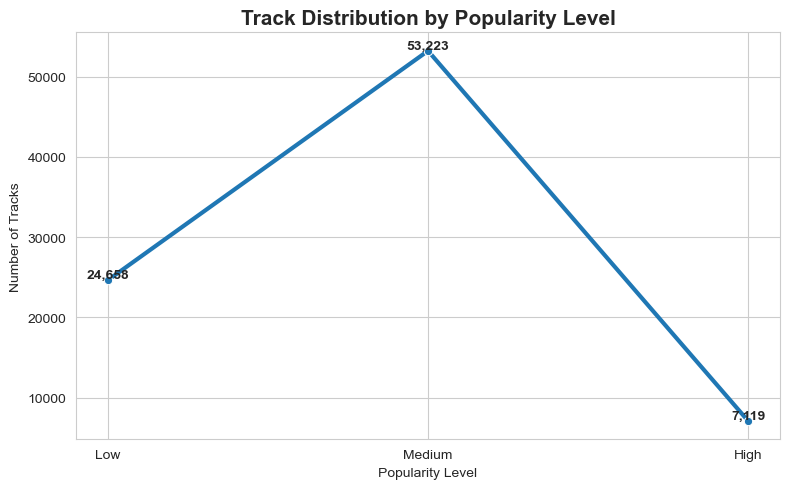

In [17]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$popularity_level",
            "Track Count": {"$sum": 1}
        }
    }
]))
counts = df['popularity_level'].value_counts()
counts = counts.reindex(['Low', 'Medium', 'High'])

plt.figure(figsize=(8,5))
ax = sns.lineplot(x=counts.index,y=counts.values,marker='o',linewidth=3)
for x, y in zip(counts.index, counts.values):
    plt.text(x, y + 300, f"{y:,}",ha='center',fontsize=10,weight='bold')
plt.title("Track Distribution by Popularity Level",fontsize=15,weight='bold')
plt.xlabel("Popularity Level")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

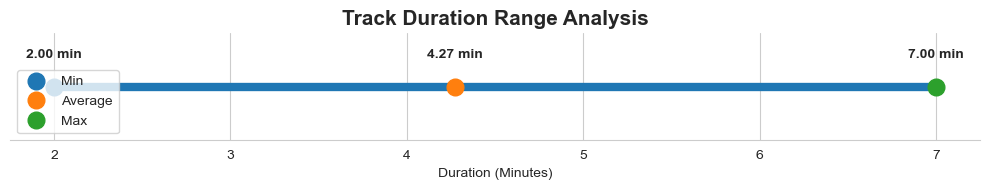

In [18]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": None,
            "maxTime": {"$max": "$duration_minutes"},
            "minTime": {"$min": "$duration_minutes"},
            "avgTime": {"$avg": "$duration_minutes"}
        }
    }
]))
min_time = result[0]["minTime"]
max_time = result[0]["maxTime"]
avg_time = result[0]["avgTime"]
plt.figure(figsize=(10,2))

plt.hlines(y=1,xmin=min_time,xmax=max_time,linewidth=6)
plt.plot(min_time, 1, 'o', markersize=12, label='Min')
plt.plot(avg_time, 1, 'o', markersize=12, label='Average')
plt.plot(max_time, 1, 'o', markersize=12, label='Max')

plt.text(min_time,1.03,f'{min_time:.2f} min',ha='center',fontsize=10,weight='bold')
plt.text(avg_time,1.03,f'{avg_time:.2f} min',ha='center',fontsize=10,weight='bold')
plt.text(max_time,1.03,f'{max_time:.2f} min',ha='center',fontsize=10,weight='bold')
plt.title("Track Duration Range Analysis",fontsize=15, weight='bold')
plt.xlabel("Duration (Minutes)")
plt.yticks([])
plt.legend()
sns.despine(left=True)
plt.tight_layout()
plt.show()

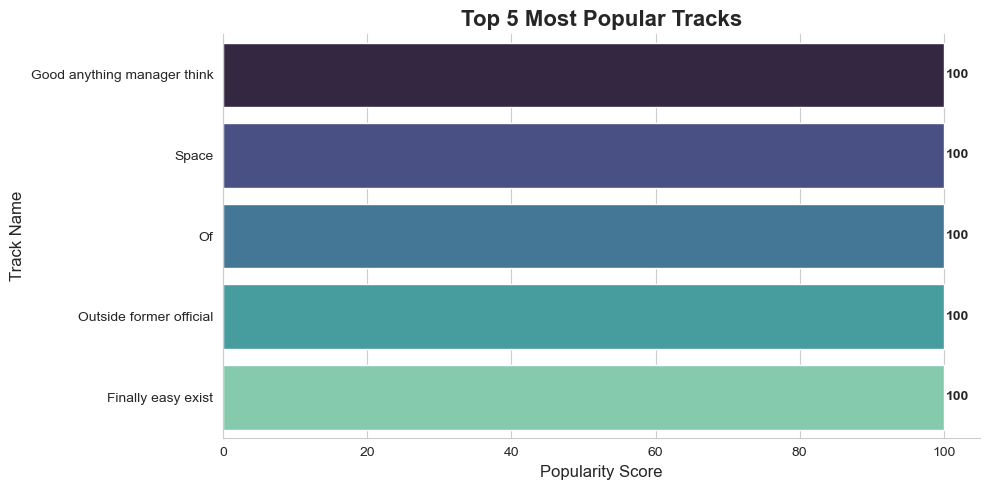

In [19]:
result = list(tracks.find(
    {"popularity": {"$gte": 90}},
    {"_id": 0, "track_name": 1, "popularity": 1}
).sort("popularity", -1).limit(5))


df = pd.DataFrame(result)
plt.figure(figsize=(10,5))

ax = sns.barplot(data=df, x="popularity", y="track_name",palette="mako")
plt.title( "Top 5 Most Popular Tracks",fontsize=16,weight='bold')
plt.xlabel("Popularity Score", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2,f'{width:.0f}',va='center',fontsize=10, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

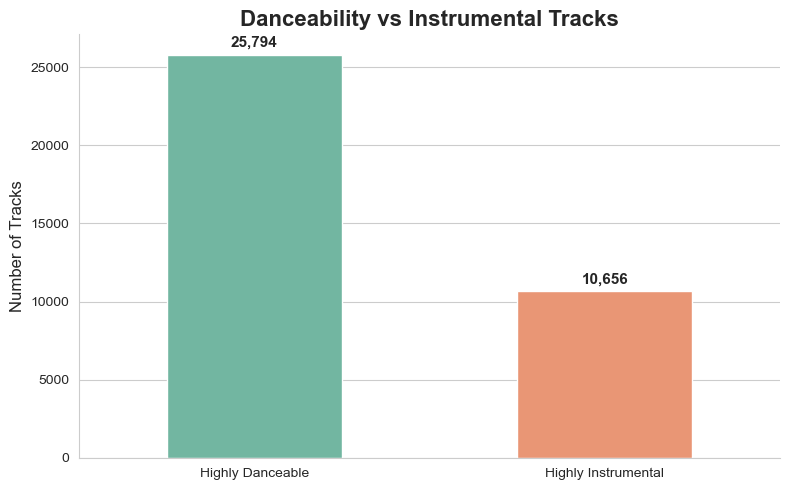

In [21]:
danceable_count = tracks.count_documents({ "danceability": {"$gt": 0.7}})
instrumental_count = tracks.count_documents({"instrumentalness": {"$gt": 0.7}})

df = pd.DataFrame({
    "Category": ["Highly Danceable", "Highly Instrumental"],
    "Track Count": [danceable_count, instrumental_count]
})
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df,x="Category",y="Track Count",palette="Set2",width=0.5)
plt.title("Danceability vs Instrumental Tracks",fontsize=16,weight='bold')

for p in ax.patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2,height + 500,f'{int(height):,}', ha='center',fontsize=11,weight='bold')

plt.xlabel("")
plt.ylabel("Number of Tracks", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

In [37]:
len(df1[df1['popularity']>80])

2737

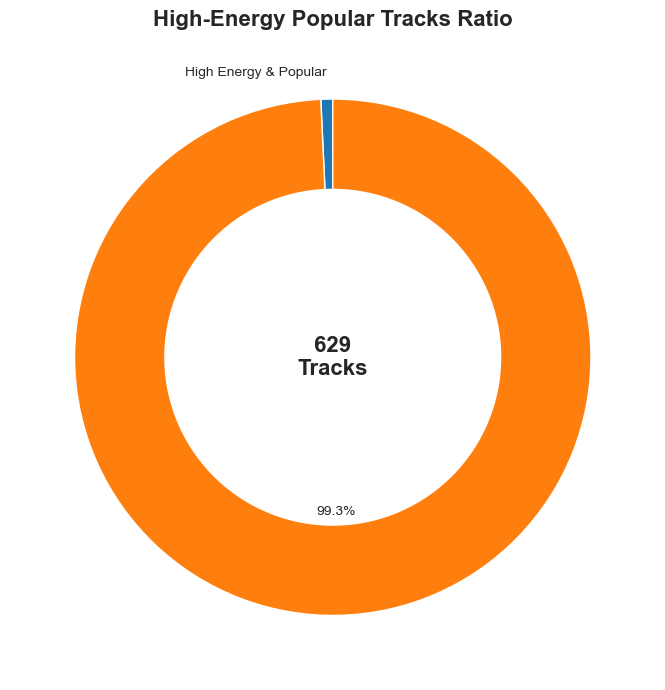

In [32]:
count = tracks.count_documents({
    "energy": {"$gt": 0.75},
    "popularity": {"$gt": 80}
})

total_tracks = tracks.count_documents({})
remaining = total_tracks - count
plt.figure(figsize=(7,7))

plt.pie([count, remaining], labels=["High Energy & Popular", ""],autopct=lambda p: f'{p:.1f}%' if p > 5 else '',startangle=90,
        wedgeprops={'width':0.35})
plt.text(0, 0, f'{count:,}\nTracks', ha='center',va='center',fontsize=16, weight='bold')
plt.title("High-Energy Popular Tracks Ratio", fontsize=16,weight='bold')
plt.tight_layout()
plt.show()

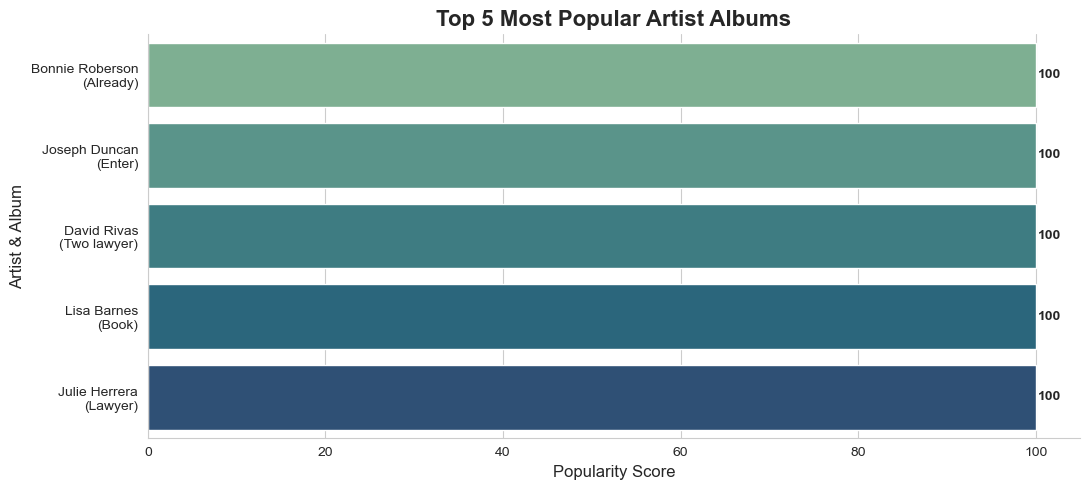

In [33]:
result = list(tracks.aggregate([
    {"$sort": {"popularity": -1}},
    {"$limit": 5},
    {
        "$project": {
            "_id": 0,
            "artist_name": 1,
            "album_name": 1,
            "popularity": 1
        }
    }
]))

df = pd.DataFrame(result)
df["Artist & Album"] = ( df["artist_name"] + "\n(" + df["album_name"] + ")")

plt.figure(figsize=(11,5))
ax = sns.barplot(data=df,x="popularity",y="Artist & Album", palette="crest")
plt.title( "Top 5 Most Popular Artist Albums",fontsize=16,weight='bold')
plt.xlabel("Popularity Score", fontsize=12)
plt.ylabel("Artist & Album", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    plt.text( width + 0.3, p.get_y() + p.get_height()/2,f'{width:.0f}',va='center',fontsize=10,weight='bold' )

sns.despine()
plt.tight_layout()
plt.show()

In [38]:
df1['genre'].value_counts().sort_values()

genre
EDM          6894
Reggaeton    7001
Indie        7007
Country      7030
Folk         7080
R&B          7084
Pop          7096
Rock         7113
Classical    7158
Hip-Hop      7160
Jazz         7177
Metal        7200
Name: count, dtype: int64

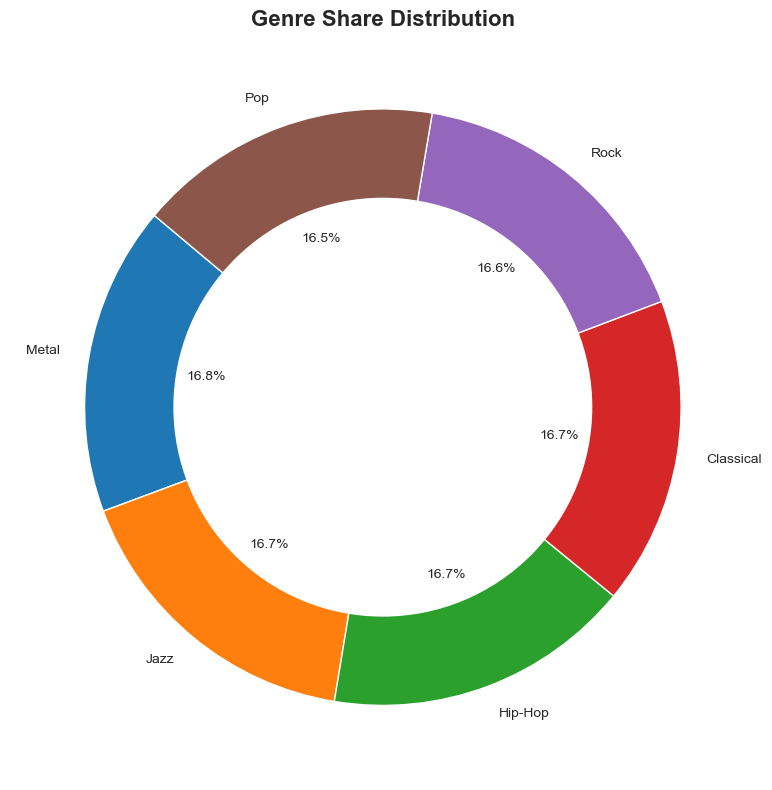

In [23]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$genre",
            "count": {"$sum": 1}
        }
    }
]))

df = pd.DataFrame(result)
df.columns = ["Genre", "Track Count"]
df = df.dropna()
df = df.sort_values("Track Count", ascending=False).head(10)

top_df = df.head(6)
plt.figure(figsize=(8,8))
plt.pie(top_df["Track Count"],labels=top_df["Genre"],autopct='%1.1f%%',startangle=140)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Genre Share Distribution",fontsize=16,weight='bold')
plt.tight_layout()
plt.show()

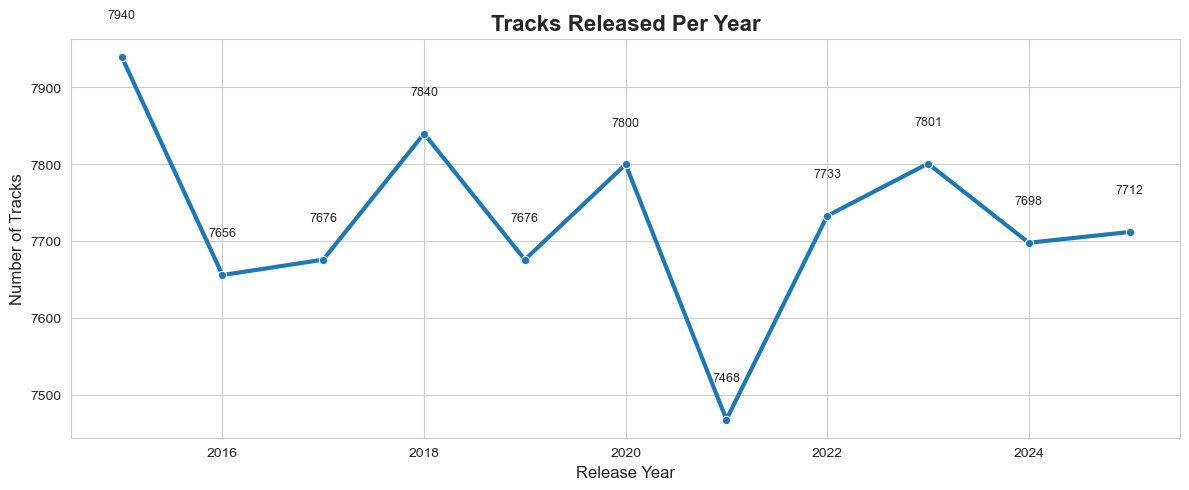

In [24]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$release_year",
            "count": {"$sum": 1}
        }
    }
]))

df = pd.DataFrame(result)
df.columns = ["Release Year", "Track Count"]
df = df.sort_values("Release Year")
plt.figure(figsize=(12,5))

ax = sns.lineplot(data=df,x="Release Year",y="Track Count",marker="o",linewidth=3)
plt.title("Tracks Released Per Year",fontsize=16,weight='bold')
for x, y in zip(df["Release Year"], df["Track Count"]):
    plt.text(x,y + 50,f'{y}',ha='center',fontsize=9)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Tracks", fontsize=12)
plt.tight_layout()
plt.show()

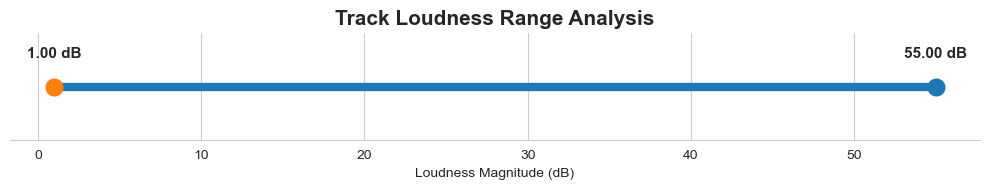

In [25]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": 0,
            "maxLoud": {"$max": "$loudness"},
            "minLoud": {"$min": "$loudness"}
        }
    }
]))

min_loud = abs(result[0]["minLoud"])
max_loud = abs(result[0]["maxLoud"])
plt.figure(figsize=(10,2))
plt.hlines(y=1,xmin=min_loud,xmax=max_loud,linewidth=6)
plt.plot(min_loud, 1, 'o', markersize=12)
plt.plot(max_loud, 1, 'o', markersize=12)
plt.text(min_loud,1.03,f'{min_loud:.2f} dB',ha='center',fontsize=11,weight='bold')
plt.text(max_loud,1.03,f'{max_loud:.2f} dB',ha='center',fontsize=11,weight='bold')
plt.title("Track Loudness Range Analysis",fontsize=15,weight='bold')
plt.xlabel("Loudness Magnitude (dB)")
plt.yticks([])
sns.despine(left=True)
plt.tight_layout()
plt.show()

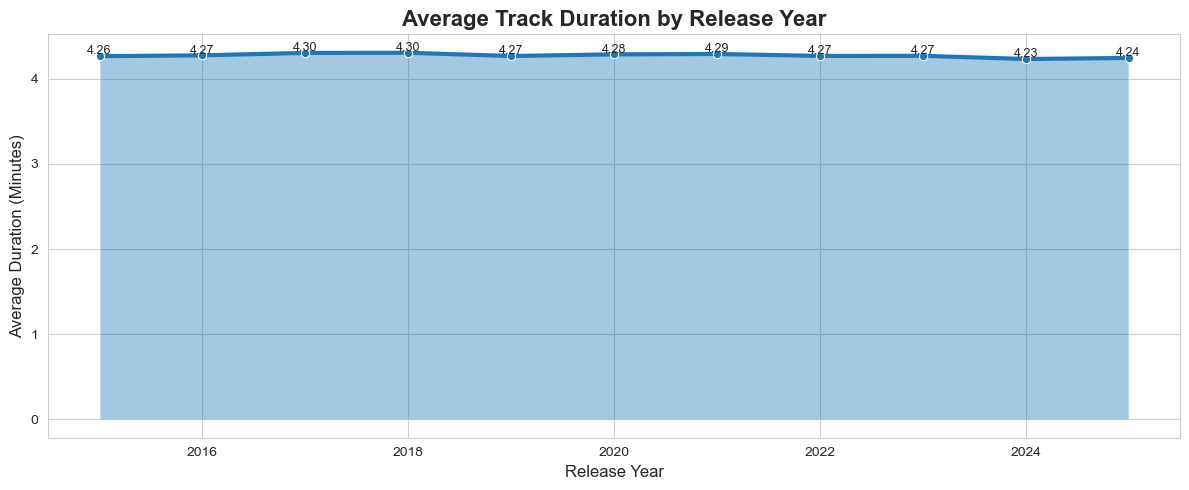

In [26]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$release_year",
            "avgDuration": {"$avg": "$duration_minutes"}
        }
    }
]))

df = pd.DataFrame(result)
df.columns = ["Release Year", "Average Duration"]
df = df.sort_values("Release Year")
plt.figure(figsize=(12,5))

plt.fill_between(df["Release Year"],df["Average Duration"],alpha=0.4)
sns.lineplot(data=df, x="Release Year",y="Average Duration", marker="o", linewidth=3)

plt.title("Average Track Duration by Release Year",fontsize=16, weight='bold')
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Average Duration (Minutes)", fontsize=12)
for x, y in zip(df["Release Year"], df["Average Duration"]):
    plt.text( x, y + 0.02,f'{y:.2f}',ha='center',fontsize=9)
plt.tight_layout()
plt.show()

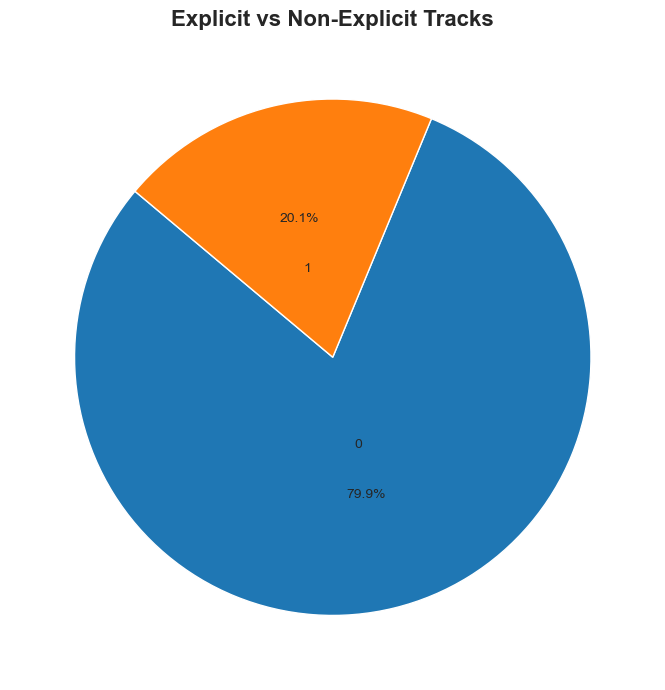

In [27]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$explicit",
            "count": {"$sum": 1}
        }
    }
]))

df = pd.DataFrame(result)
df.columns = ["Explicit Content", "Track Count"]
df["Explicit Content"] = df["Explicit Content"].replace({
    True: "Explicit",
    False: "Non-Explicit"
})

plt.figure(figsize=(7,7))
plt.pie(df["Track Count"], labels=df["Explicit Content"], autopct='%1.1f%%',startangle=140, pctdistance=0.55,labeldistance=0.35)
plt.title("Explicit vs Non-Explicit Tracks",fontsize=16,weight='bold')
plt.tight_layout()
plt.show()

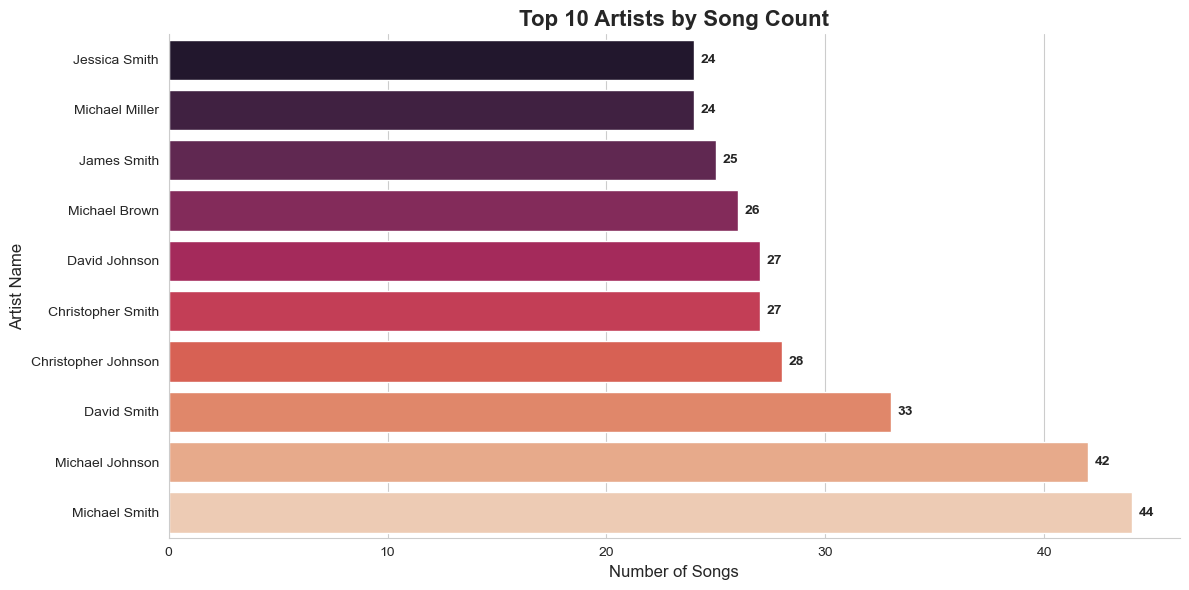

In [28]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$artist_name",
            "total": {"$sum": 1}
        }
    },
    {"$sort": {"total": -1}},
    {"$limit": 10}
]))
df = pd.DataFrame(result)
df.columns = ["Artist Name", "Track Count"]
df = df.sort_values("Track Count", ascending=True)

plt.figure(figsize=(12,6))
ax = sns.barplot( data=df,x="Track Count",y="Artist Name",palette="rocket")
plt.title("Top 10 Artists by Song Count",fontsize=16,weight='bold')
plt.xlabel("Number of Songs", fontsize=12)
plt.ylabel("Artist Name", fontsize=12)
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3,p.get_y() + p.get_height()/2,f'{int(width)}',va='center',fontsize=10,weight='bold' )
sns.despine()
plt.tight_layout()
plt.show()

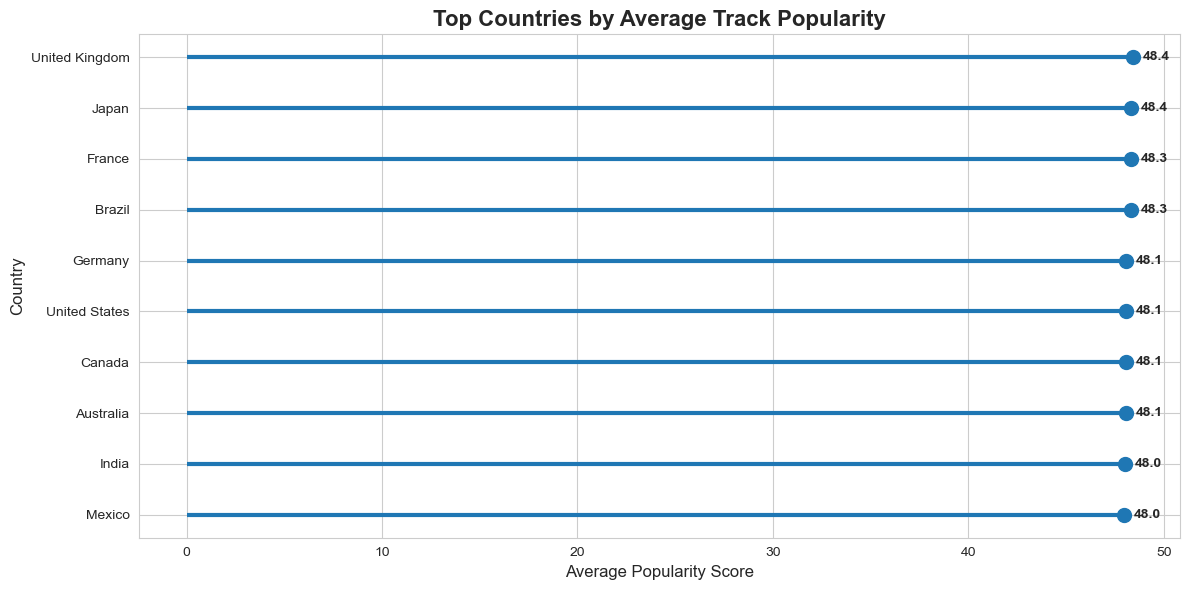

In [29]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$country",
            "avgPop": {"$avg": "$popularity"},
            "totalTracks": {"$sum": 1}
        }
    },
    {"$sort": {"avgPop": -1}}
]))

df = pd.DataFrame(result)
df.columns = ["Country", "Average Popularity", "Total Tracks"]
df = df.dropna()
df = df.head(10)
df = df.sort_values("Average Popularity", ascending=True)

plt.figure(figsize=(12,6))
plt.hlines(y=df["Country"],xmin=0, xmax=df["Average Popularity"], linewidth=3)
plt.plot( df["Average Popularity"], df["Country"], "o", markersize=10)

for x, y in zip(df["Average Popularity"], df["Country"]):
    plt.text( x + 0.5, y, f'{x:.1f}', va='center', fontsize=10,weight='bold' )
plt.title("Top Countries by Average Track Popularity", fontsize=16, weight='bold')
plt.xlabel("Average Popularity Score", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

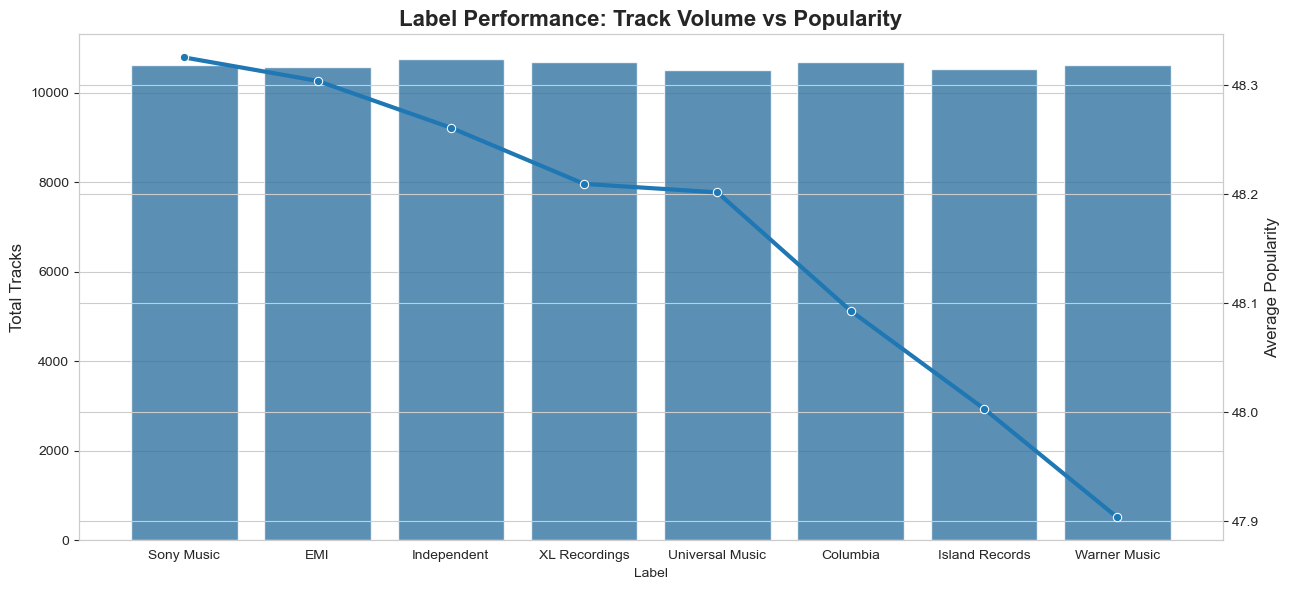

In [30]:
result = list(tracks.aggregate([
    {
        "$group": {
            "_id": "$label",
            "avgPop": {"$avg": "$popularity"},
            "totalTrack": {"$sum": 1}
        }
    },
    {"$sort": {"avgPop": -1}}
]))

df = pd.DataFrame(result)
df.columns = ["Label", "Average Popularity", "Total Tracks"]
df = df.dropna()
df = df.head(10)

fig, ax1 = plt.subplots(figsize=(13,6))
sns.barplot(data=df,x="Label", y="Total Tracks",ax=ax1,alpha=0.8)
ax2 = ax1.twinx()
sns.lineplot(data=df, x="Label",y="Average Popularity",marker="o",linewidth=3, ax=ax2)

ax1.set_title( "Label Performance: Track Volume vs Popularity", fontsize=16,weight='bold')
ax1.set_ylabel("Total Tracks", fontsize=12)
ax2.set_ylabel("Average Popularity", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

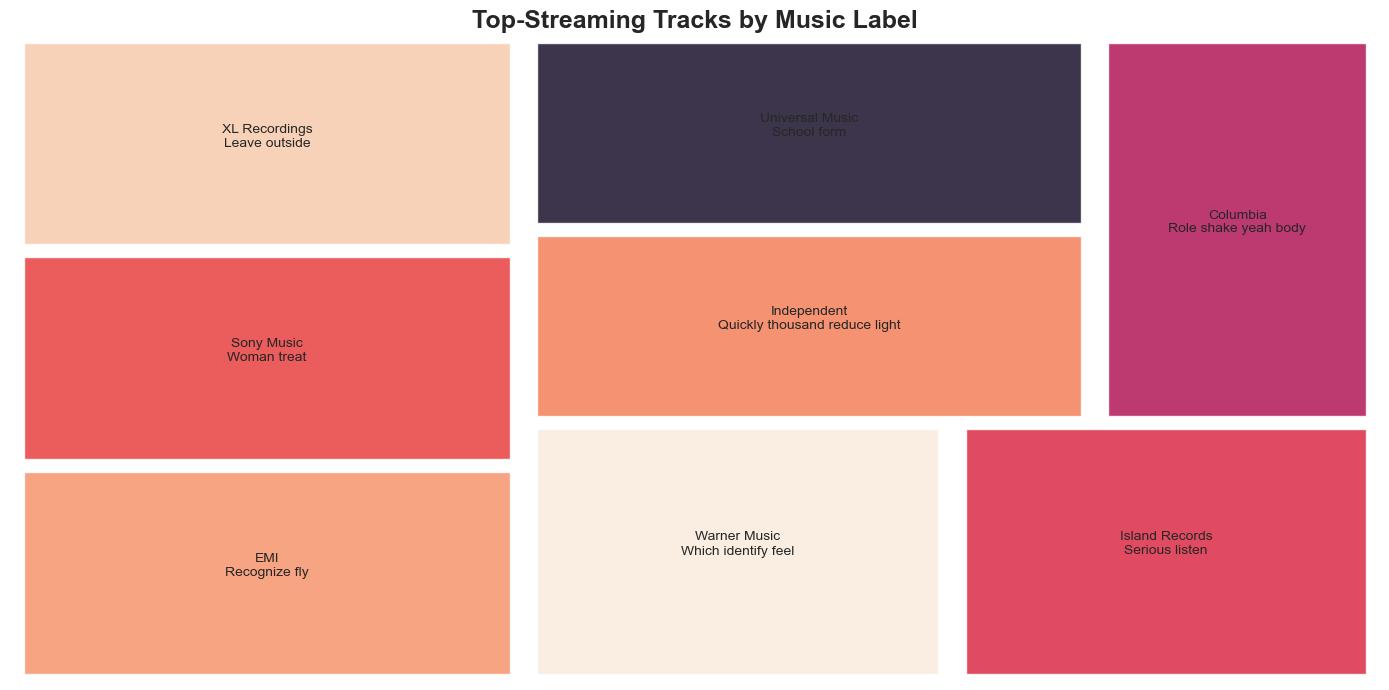

In [31]:
import squarify
result = list(tracks.aggregate([
    {"$sort": {"stream_count": -1}},
    {
        "$group": {
            "_id": "$label",
            "topTrack": {"$first": "$track_name"},
            "artist": {"$first": "$artist_name"},
            "maxStreams": {"$first": "$stream_count"}
        }
    },
    {"$sort": {"maxStreams": -1}},
    {"$limit": 10}
]))

data = []
for doc in result:
    data.append({
        "Label": doc["_id"],
        "Track": doc["topTrack"],
        "Artist": doc["artist"],
        "Streams": doc["maxStreams"]
    })

df = pd.DataFrame(data)
labels = [f"{row['Label']}\n{row['Track']}\n" for _, row in df.iterrows()]

plt.figure(figsize=(14,7))
squarify.plot(sizes=df["Streams"],label=labels,alpha=0.85,pad=True)
plt.axis("off")
plt.title("Top-Streaming Tracks by Music Label",fontsize=18,weight='bold')
plt.tight_layout()
plt.show()